# 1. Spatially-informed bivariate metrics

This tutorial provides an overview of the local and global scores implemented in LIANA+. These scores are used to identify spatially co-expressed ligand-receptor pairs. However, there also applicable to other types of spatially-informed bivariate analyses.
It provides brief explanations of the mathematical formulations of the scores; these include adaptation of bivariate Moran’s R, Pearson correlation, Spearman correlation, weighted Jaccard similarity, and Cosine similarity. The tutorial also showcases interaction categories (masks) and significance testing.

### Environement Setup

In [1]:
import pandas as pd
import scanpy as sc
import squidpy as sq
import decoupler as dc
import liana as li
from matplotlib import pyplot as plt
# set dpi to 100, to make the notebook smaller
plt.rcParams['figure.dpi'] = 100

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load and Normalize Data

In [2]:
# li.ds caches downloads under ../../data/anndata; a provided Visium_19_CK297.h5ad there is used as-is
sc.settings.datasetdir = "../../data"
adata = li.ds.kuppe_2022()
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

### Available spatial corelation/similarity Functions

In [3]:
li.mt.bivariate.show_functions()

,name,metadata,reference
0,pearson,weighted Pearson correlation coefficient,NaN
1,spearman,weighted Spearman correlation coefficient,NaN
2,cosine,weighted Cosine similarity,NaN
3,jaccard,weighted Jaccard similarity,NaN
4,product,simple weighted product,If vars are z-scaled = Lee's statistic (Lee 20...
5,norm_product,normalized weighted product,NaN
6,morans,Moran's R,"Li, Z., Wang, T., Liu, P. and Huang, Y., 2022...."
7,masked_spearman,masked & weighted Spearman correlation,"Ghazanfar, S., Lin, Y., Su, X., Lin, D.M., Pat..."


### How do the local functions work?

The local functions work are quite simple, as they are simply weighted versions of well-known similarity metrics. For example, the spatially-weighted version of Cosine similarity is defined as:

$$ \text{wCosine}_i = \frac{\sum_{j=1}^n w_{ij} x_j y_j}{\sqrt{\sum_{j=1}^n w_{ij} x_j^2} \sqrt{\sum_{j=1}^n w_{ij} y_j^2}}$$

where for each spot **i**, we perform summation over all spots **n**, where **w**​ represents the spatial connectivity weights from spot **i** to every other spot **j**;  for variables  **x** and **y**.

### How do the global functions work?

Global scores can be calculated as the average local score across all spots for each ligand-receptor pair.

In addition, we can also use Global bivariate Moran's R (or [Lee's statistic](https://onlinelibrary.wiley.com/doi/full/10.1111/gean.12106)) - an extension of univariate Moran's I, as proposed by [Anselin 2019](https://onlinelibrary.wiley.com/doi/full/10.1111/gean.12164) and [Lee and Li, 2019](https://onlinelibrary.wiley.com/doi/full/10.1111/gean.12106); implemented in [SEAGAL](https://academic.oup.com/bioinformatics/article/39/7/btad431/7223197) and [SpatialDM](https://github.com/StatBiomed/SpatialDM).



### Spatial Connectivity

The way that spatially-informed methods usually work is by making use of weights based on the proximity (or spatial connectivity) between spots/cells.
These spatial connectivities are then used to calculate the metric of interest, e.g. Cosine similarity, in a spatially-informed manner.

The spatial weights in LIANA+ are by default defined as a family of radial kernels that use the inverse Euclidean distance between cells/spots to bind the weights between 0 and 1, with spots that are closest having the highest spatial connectivity to one another (1), while those that are thought to be too far to be in contact are assigned 0.

Key parameters of spatial_neighbors include:
- `bandwidth` controls the radius of the spatial connectivities where higher values will result in a broader area being considered (controls the radius relative to the coordinates stored in `adata.obsm['spatial']`)
- `cutoff` controls the minimum value that will be considered to have a spatial relationship (anything lower than the `cutoff` is set to 0).
- `kernel` controls the distribution (shape) of the weights ('gaussian' by default)
- `set_diag` sets the diagonal (i.e. the weight for each spot to itself) to 1 if True. **NOTE**: Here we set it to True as we expect many cells to be neighbors of themselves within a visium spot

As choosing an optimal bandwidith can be tricky, we provide the ``query_bandwidth`` function which uses a set of coordinates to provide an estimate of how many cell or spot neighbors are being considered for each spot over a range of bandwidths. 

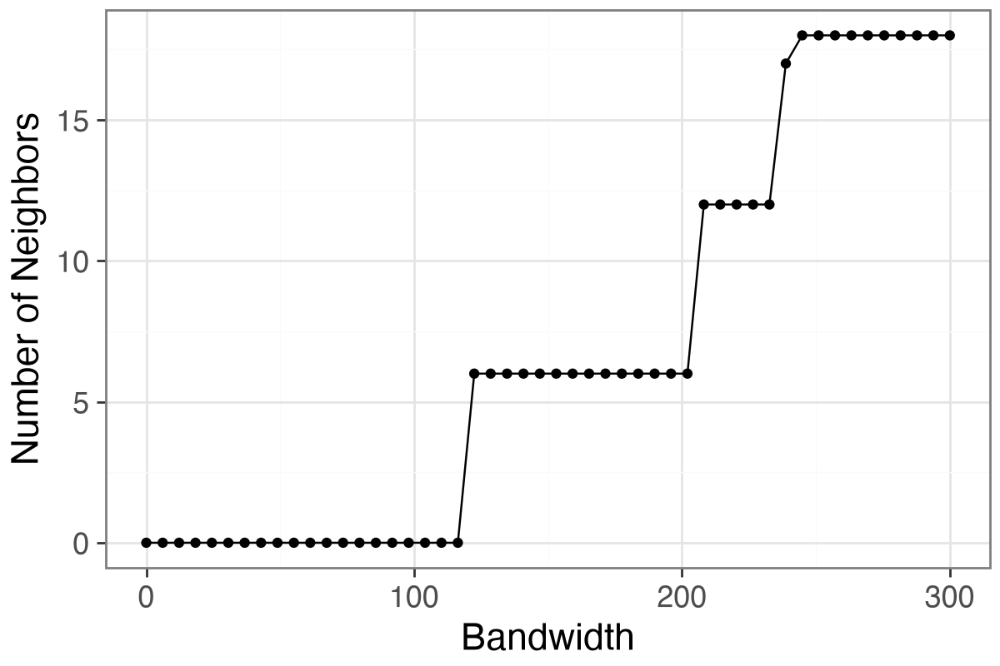

In [4]:
plot, _ = li.pp.query_bandwidth(coordinates=adata.obsm['spatial'], start=0, end=300, interval_n=50)
plot


Here, we can see that a bandwidth of 130-200 (pixels) roughly includes 6 neighbours i.e. the first ring of neighbours in the hexagonal grid of 10x Visium. So, we will build the spatial graph with a bandwidth of 150.

In [5]:
li.pp.spatial_neighbors(adata, bandwidth=150, cutoff=0.1, kernel='gaussian', set_diag=True)

Let's visualize the spatial weights for a single spot to all other spots in the dataset:

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_88158/2395490402.py:1: UserWarning: This function will be deprecated in the next version. Please use scanpy or squidpy for plotting spatial connectivities.


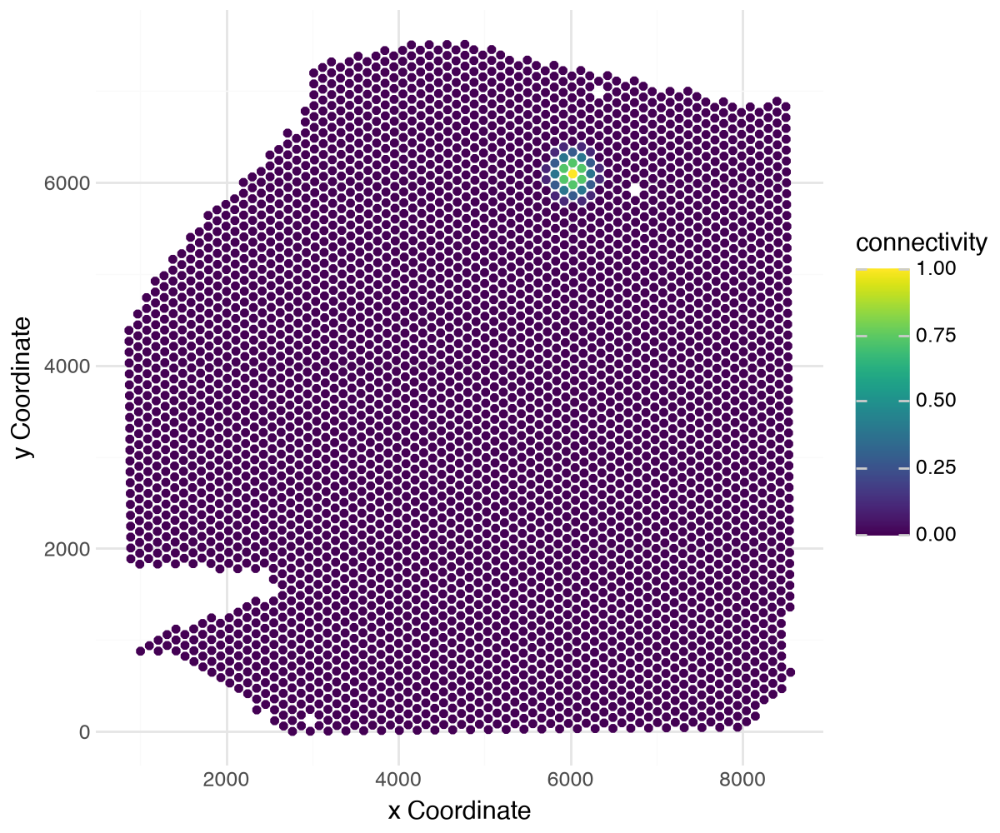

In [6]:
li.pl.connectivity(adata, idx=0, size=1.3, figure_size=(6, 5)) 

### Bivariate Ligand-Receptor Relationships

Now that we have covered the basics, let's see how these scores look for potential ligand-receptor interactions on our 10X Visium Slide.
Note that LIANA+ will take the presence of heteromeric complexes into account at the individual spot-level!

In [7]:
lrdata = li.mt.bivariate(adata,
                resource_name='consensus', # uses HUMAN gene symbols
                local_name='cosine', # Name of the local function
                global_name="morans", # Name global function (or 'lee')
                n_perms=None, # Number of permutations to calculate a p-value
                mask_negatives=False, # Whether to mask LowLow/NegativeNegative interactions
                add_categories=True, # Whether to add local categories to the results
                nz_prop=0.3, # Minimum expr. proportion for ligands/receptors and their subunits
                use_raw=False,
                verbose=True
                )

Using `.X`!


Using resource `consensus`.


In [8]:
lrdata

AnnData object with n_obs × n_vars = 4113 × 472
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche'
    var: 'ligand', 'receptor', 'ligand_means', 'ligand_props', 'receptor_means', 'receptor_props', 'morans', 'morans_pvals', 'mean', 'std'
    uns: 'spatial', 'log1p'
    obsm: 'compositions', 'mt', 'spatial'
    obsp: 'spatial_connectivities'
    layers: None (.X), 'cats'

#### Global scores

In [9]:
lrdata.var.sort_values("mean", ascending=False).head(5)

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
TIMP1^CD63,TIMP1,CD63,3.048890,0.996839,2.887192,0.994165,0.035044,None,0.982511,0.016920
LGALS1^ITGB1,LGALS1,ITGB1,3.534027,0.997326,2.457884,0.988330,0.164461,None,0.979006,0.031898
LUM^ITGB1,LUM,ITGB1,3.173511,0.996353,2.457884,0.988330,-0.112610,None,0.964954,0.030367
CD99^CD81,CD99,CD81,2.199851,0.980063,2.558025,0.990761,0.037857,None,0.962681,0.038179
HSPG2^ITGB1,HSPG2,ITGB1,2.243123,0.986142,2.457884,0.988330,0.009551,None,0.961398,0.035274


The columns 'mean' represent the average cosine local score across all spots and the p-value calculated from permutations, respectively.

The column 'morans' represents the global Moran's R score for each ligand-receptor pair.Bivariate Moran's R values near zero imply spatial independence, while positive or negative values reflect spatial co-clustering or spatial cross-dispersion, respectively.

In [10]:
lrdata.var.sort_values("morans", ascending=False).head()

,ligand,receptor,ligand_means,ligand_props,receptor_means,receptor_props,morans,morans_pvals,mean,std
interaction,,,,,,,,,,
APOE^LRP1,APOE,LRP1,1.179983,0.752006,1.937682,0.956236,0.297608,None,0.801679,0.153762
S100A1^RYR2,S100A1,RYR2,0.697087,0.572332,0.430792,0.406516,0.286779,None,0.479849,0.280113
SERPING1^LRP1,SERPING1,LRP1,1.711175,0.931437,1.937682,0.956236,0.261377,None,0.906441,0.085398
VTN^ITGAV_ITGB1,VTN,ITGAV_ITGB1,0.434514,0.395089,1.713479,0.929006,0.260025,None,0.580779,0.252194
COL1A1^ITGA11_ITGB1,COL1A1,ITGA11_ITGB1,5.487195,1.000000,0.719829,0.643812,0.245056,None,0.764013,0.114057


From these Global summaries, we see that the average Cosine similarity largely represents **coverage** - e.g. *TIMP1 & CD63* is ubiquoutesly and uniformly distributed across the slide. 

On the other hand, among most variable interactions and with with the highest global morans R is e.g. **APOE^LRP1**. This interaction is thus more likely to represent biological relationships, with distinct spatial clustering patterns.

So, let's visualize both:

In [11]:
sc.set_figure_params(dpi=80, dpi_save=300, format='png', frameon=False, transparent=True, figsize=[5,5])

... storing 'ligand' as categorical


... storing 'receptor' as categorical


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


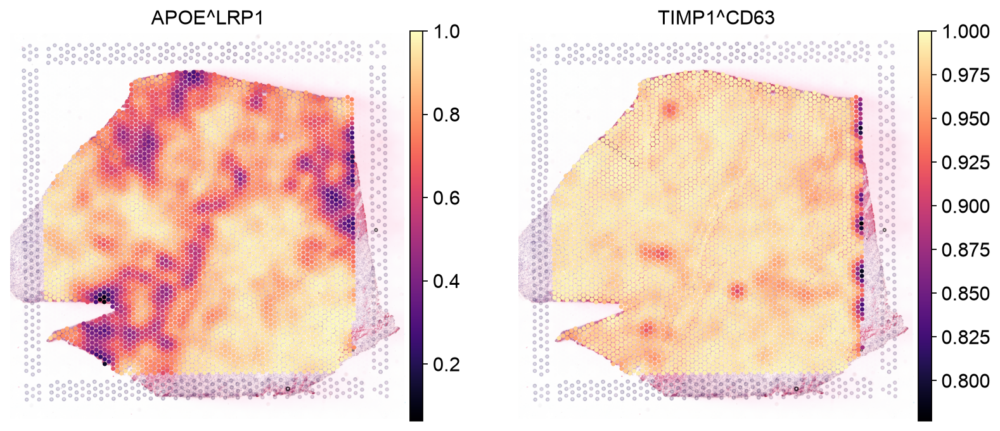

In [12]:
sq.pl.spatial_scatter(lrdata, color=['APOE^LRP1', 'TIMP1^CD63'], size=1.4, vmax=1, cmap='magma')
plt.show()

As expected, we see that the **TIMP1 & CD63** interaction is uniformly distributed across the slide, while **APOE^LRP1** shows a clear spatial pattern.

We can also see that this is the case when we look at the individual genes:

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


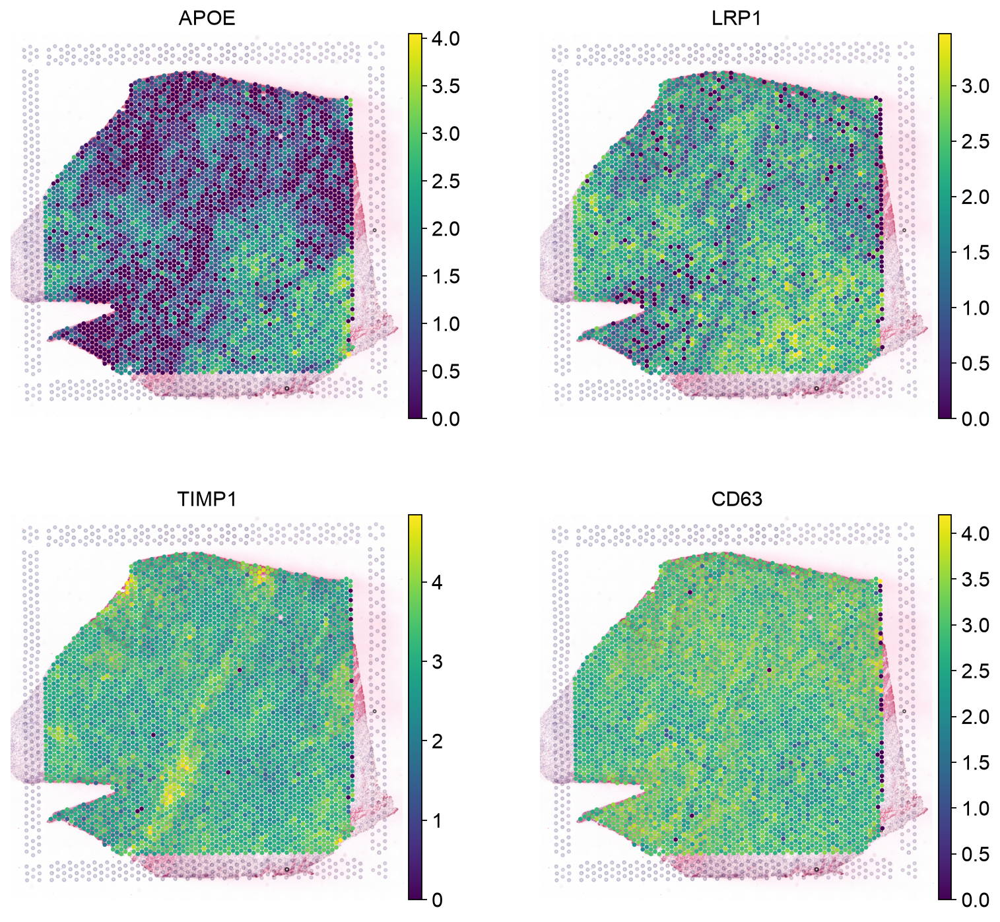

In [13]:
sq.pl.spatial_scatter(adata, color=['APOE', 'LRP1',  'TIMP1', 'CD63'],
                       size=1.4, ncols=2)
#sq.pl.spatial_scatter(adata, color=['VTN', 'ITGAV', 'ITGB5', 'TIMP1', 'CD63'], size=1.2, ncols=2)  # you can also use `squidpy.pl.spatial_scatter` instead.
plt.show()

### Permutation-based p-values
In addition to the local scores, we also calculated permutation-based p-values based on a null distribution generated by shuffling the spot labels. 

---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise — Does the local metric matter?**

The local scores above use `local_name='cosine'`. Re-run `li.mt.bivariate` with
`local_name='pearson'` (keep everything else the same) and compare:

1. the top 10 interactions by `mean` local score for each metric;
2. the `morans` column of both results;
3. the local score maps of `APOE^LRP1` with each metric.

Why do the rankings by `mean` differ so much, while `morans` does not change at all?
</div>

In [14]:
# your turn
lrdata_pearson = li.mt.bivariate(adata,
                                 resource_name='consensus',
                                 local_name='pearson',
                                 global_name='morans',
                                 nz_prop=0.3,
                                 use_raw=False)

<details>
<summary><b>▶ Solution</b></summary>

```python
top_cosine = lrdata.var.sort_values('mean', ascending=False).head(10).index
top_pearson = lrdata_pearson.var.sort_values('mean', ascending=False).head(10).index
print(pd.DataFrame({'cosine': top_cosine, 'pearson': top_pearson}))
print('shared:', len(set(top_cosine) & set(top_pearson)))

# Moran's R is computed from the expression and the spatial weights only
print((lrdata.var['morans'] - lrdata_pearson.var['morans']).abs().max())

sq.pl.spatial_scatter(lrdata, color='APOE^LRP1', size=1.4, cmap='magma', title='cosine')
sq.pl.spatial_scatter(lrdata_pearson, color='APOE^LRP1', size=1.4, cmap='coolwarm',
                      vmin=-1, vmax=1, title='pearson')
plt.show()
```

The two top-10 lists share **no** interactions. Weighted cosine similarity works on
non-negative expression, so a high mean score mostly means *both genes are expressed
everywhere* (coverage, e.g. `TIMP1^CD63`). Weighted Pearson centres each gene first, so it
ranges from −1 to 1 and rewards pairs whose **deviations from the mean** co-vary locally —
its top list is dominated by collagen–integrin pairs (`COL1A1^ITGA11_ITGB1`, …) that are
high together in the fibrotic regions. That is also why its map needs a diverging colour
scale centred on 0, while cosine uses a sequential one.

`morans` is identical because the global score is computed independently of the local
function. So the local metric is a modelling choice about *what "co-expressed here" means*;
pick it for the question you are asking, and use the global score to find spatially
variable pairs.

</details>

## Beyond Ligand-Receptors (optional)

While protein-mediated ligand-receptor interactions are interesting, cell-cell communication is not limited to those alone. Rather it is a complex process that involves a variety of different mechanisms such as signalling pathways, metabolite-mediated signalling, and distinct cell types.

So, if such diverse mechanisms are involved in cell-cell communication, why should we limit ourselves to ligand-receptor interactions?
Let's see how we can use LIANA+ to explore other types of cell-cell communication.

One simple approach would be to check relationships e.g. between transcription factors and cell type proportions.

### Extract Cell type Composition
This slide comes with estimated cell type proportions using cell2location; See [Kuppe et al., 2022](https://www.nature.com/articles/s41586-022-05060-x). Let's extract from .obsm them to an independent AnnData object.

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


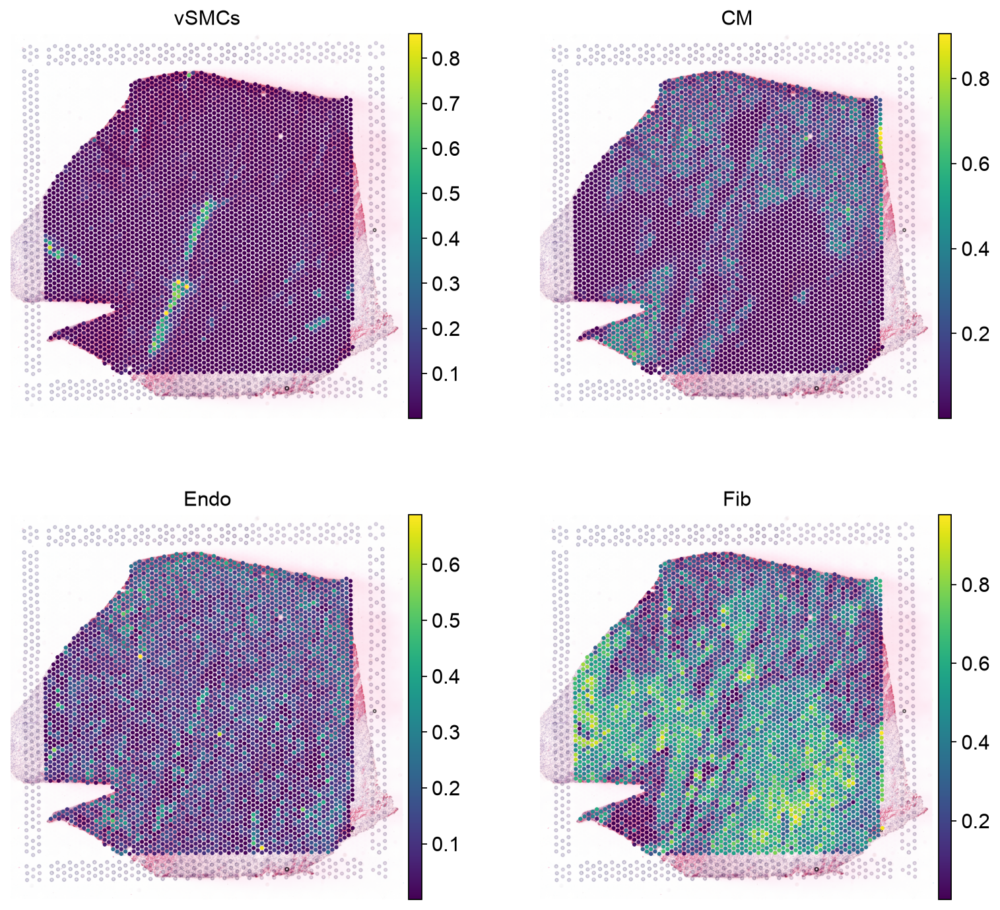

In [15]:
# let's extract those
comps = li.pp.obsm_to_adata(adata, 'compositions')
# check key cell types
sq.pl.spatial_scatter(comps, color=['vSMCs','CM', 'Endo', 'Fib'], size=1.3, ncols=2)
plt.show()

### Estimate Transcription Factor Activity

In [16]:
# Get transcription factor resource
net = dc.op.collectri(organism='human', remove_complexes=True, license='academic', verbose=False)

While multi-omics datasets might be even more of an interest, for the sake of simplicity (and because the general lack of spatial mutli-omics data at current times), let's instead use enrichment analysis to estimate the activity of transcription factors in each spot. We will use one of [decoupler-py's](https://decoupler-py.readthedocs.io/en/latest/index.html) enrichment methods with [CollectTRI](https://www.biorxiv.org/content/10.1101/2023.03.30.534849v1.abstract) to do so. Refer to this [tutorial](https://decoupler-py.readthedocs.io/en/latest/notebooks/dorothea.html) for more info.

In [17]:
# Estimate activities
dc.mt.ulm(
    data=adata,
    net=net,
    bsize=128,  
    tmin = 50,
    verbose=True,
    raw=False
)

2026-09-25 17:14:25 | [INFO] ulm - Running ulm


ulm - Running ulm


2026-09-25 17:14:25 | [INFO] Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


Extracted omics mat with 4113 rows (observations) and 17703 columns (features)


2026-09-25 17:14:25 | [INFO] Network adjacency matrix has 4750 unique features and 170 unique sources


...


100%|██████████| 33/33 [00:00<00:00, 53.71it/s]


2026-09-25 17:14:26 | [INFO] ulm - adjusting p-values by FDR


ulm - adjusting p-values by FDR


2026-09-25 17:14:26 | [INFO] ulm - done


ulm - done


#### Extract highly-variable TF activities
To reduce the number of TFs for the sake of computational speed, we will only focus on the top 50 most variable TFs.

We will use the simple coefficient of variation to identify the most variable TFs.


In [18]:
est = li.pp.obsm_to_adata(adata, 'score_ulm')
est.var['cv'] =  est.X.std(axis=0) / est.X.mean(axis=0)
top_tfs = est.var.sort_values('cv', ascending=False, key=abs).head(50).index


Create MuData object with TF activities and cell type proportions, and transfer spatial connectivities and other information from the original AnnData object.

In [19]:
import mudata as mu
mdata = mu.MuData({"tf":est, "comps":comps})
mdata.obsp = adata.obsp
mdata.uns = adata.uns
mdata.obsm = adata.obsm

Define Interactions of interest:

In [20]:
from itertools import product

In [21]:
interactions = list(product(comps.var.index, top_tfs))

In [22]:
interactions[:5]

[('Adipo', 'IRF3'),
 ('Adipo', 'KLF2'),
 ('Adipo', 'MBD2'),
 ('Adipo', 'SIRT1'),
 ('Adipo', 'PDX1')]

### Estimate Cosine Similarity

In [23]:
bdata = li.mt.bivariate(mdata,
                        x_mod="comps",
                        y_mod="tf",
                        x_transform=sc.pp.scale,
                        y_transform=sc.pp.scale,
                        local_name="cosine", 
                        interactions=interactions,
                        mask_negatives=True, 
                        add_categories=True,
                        x_use_raw=False,
                        y_use_raw=False,
                        xy_sep="<->",
                        x_name='celltype',
                        y_name='tf'
                        )

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.


<div class="alert alert-info">

To make the distributions comparable, we simply z-scale the TF activities and cell type proportions via the `x_transform` & `y_transform` parameters.

The type of transformation will affect the interpretation of the results, and different types of transformation might be more appropriate for different types of data. We provide zero-inflated minmax `zi_minmax` & `neg_to_zero` transformation functions via `li.fun.transform`.


</div>

In [24]:
bdata.var.sort_values("mean", ascending=False).head(5)

,celltype,tf,celltype_means,celltype_props,tf_means,tf_props,mean,std
interaction,,,,,,,,
CM<->MEF2C,CM,MEF2C,-6.781192e-09,1.0,2.101297e-08,1.0,0.821639,0.139590
CM<->NKX2-5,CM,NKX2-5,-6.781192e-09,1.0,-2.590241e-09,1.0,0.807386,0.167184
CM<->SIRT1,CM,SIRT1,-6.781192e-09,1.0,-4.103640e-09,1.0,0.601110,0.212433
Fib<->CTNNB1,Fib,CTNNB1,1.338776e-08,1.0,-2.134766e-08,1.0,0.575453,0.236702
Myeloid<->IRF1,Myeloid,IRF1,9.822543e-09,1.0,-9.356881e-09,1.0,0.550529,0.215481


#### Let's plot the results

... storing 'celltype' as categorical


... storing 'tf' as categorical


/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


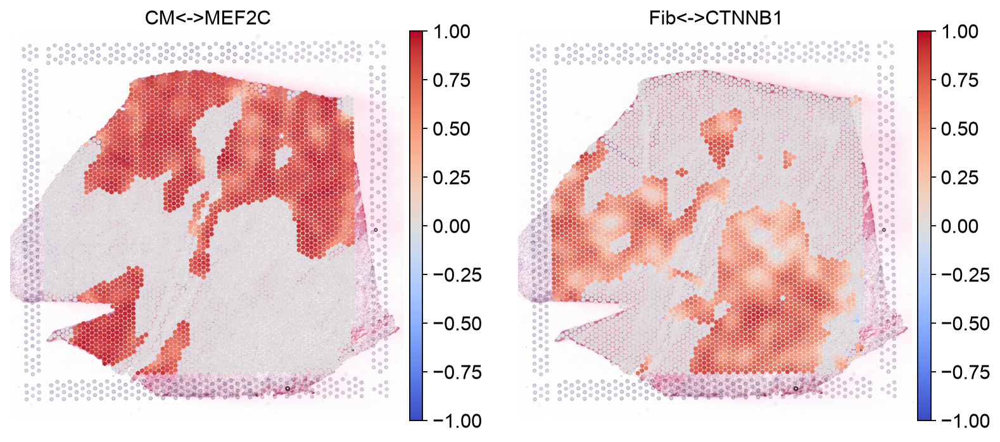

In [25]:
sq.pl.spatial_scatter(bdata, color=['CM<->MEF2C', 'Fib<->CTNNB1'], size=1.4, cmap="coolwarm", vmax=1, vmin=-1)
plt.show()

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


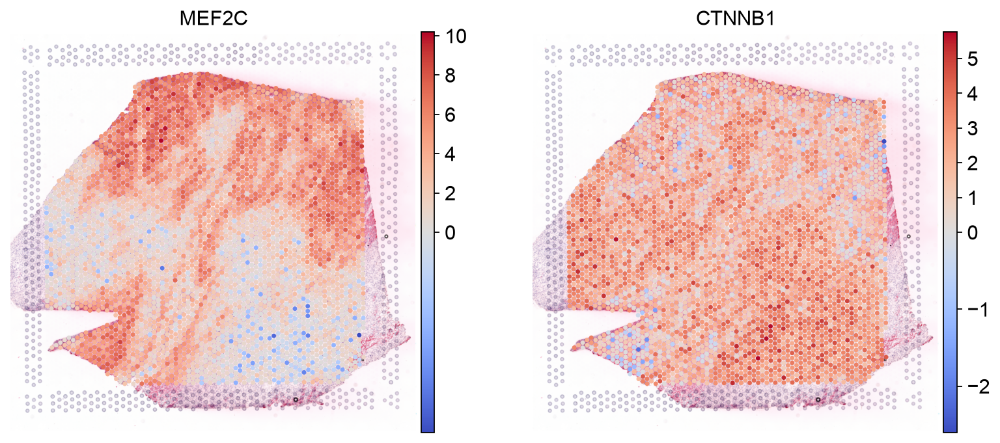

In [26]:
sq.pl.spatial_scatter(mdata.mod['tf'], color=['MEF2C', 'CTNNB1'], cmap='coolwarm', size=1.4, vcenter=0)
plt.show()

/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
/Users/b260-admin/miniforge3/envs/sc-ccc-tutorial/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`


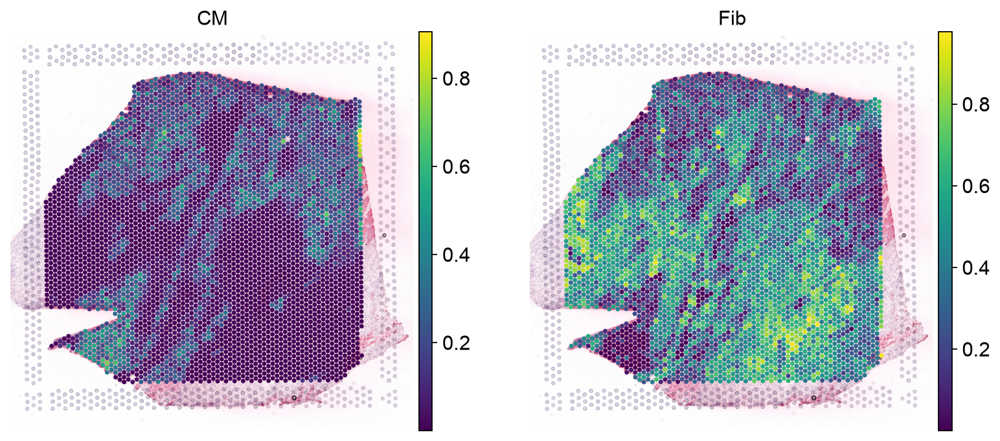

In [27]:
sq.pl.spatial_scatter(mdata.mod['comps'], color=['CM', 'Fib'], cmap='viridis', size=1.4)
plt.show()

---

**Next:** `02_misty.ipynb` moves beyond pairs of variables and learns spatial relationships with MISTy.